In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import datetime
import pytz
NYC_tz = pytz.timezone("America/New_York") 

In [2]:
import sys
sys.path.append("../../")

import rateslib as rl
import QuantLib as ql

from Query.IRSwaps.IRSwapQuery import IRSwapQuery 
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapValue import IRSwapValue

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP, _format_fly_str 
from TB.IRSwapsTB import IRSwapsTB 

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP

In [4]:
swap_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
tb = IRSwapsTB(mdp=swap_mdp)

WARNING	Task(Task-4) Caching.computed_timeseries_store:computed_timeseries_store.py:_open_duckdb_graceful()- DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


BACKTESTING...: 100%|██████████| 297/297 [00:39<00:00,  7.53step/s]


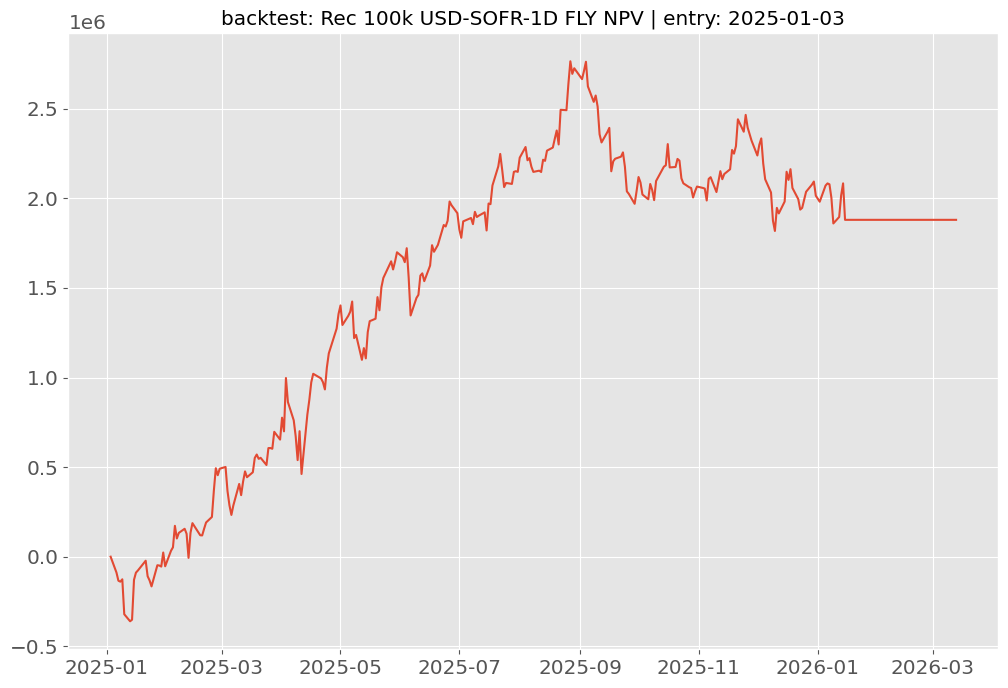

In [13]:
trade_date = datetime.date(2025, 1, 3)

query = IRSwapQuery(
    structure=IRSwapStructure.OUTRIGHT,
    value=IRSwapValue.NPV,
    curve="USD-SOFR-1D",
    tenor="3m2y/3m5y/3m10y",
    structure_kwargs={"bpv": 100_000},
)

entry = DateTrigger(DateTriggerRequirements(dates=[trade_date]), actions=[AddQueryAction(query=query)])
exit_ = DateTrigger(DateTriggerRequirements(dates=[datetime.date(2026, 1, 15)]), actions=[UnwindPositionsAction(match_all=True, fee=0.0)])

tg = TimeGrid(
    ql_cal_date_range(
        ql_cal=ql.UnitedStates(ql.UnitedStates.GovernmentBond),
        start=trade_date,
        end=datetime.date(2026, 3, 13),
    )
)
strategy = QueryStrategy(name=f"{query.col_name()}", triggers=[entry, exit_])
bt = QueryDrivenBacktest(time_grid=tg, mdp=swap_mdp, strategy=strategy)
bt.run()

mtm = pd.Series(bt.mtm_history).sort_index()
plt.figure()
plt.plot(mtm)
plt.title(f"backtest: {query.col_name()} | entry: {trade_date}")
plt.show()

PRICING USD-SOFR-1D IRSWAPS [workers=1]...: 100%|██████████| 298/298 [00:20<00:00, 14.77it/s]


,USD-SOFR-1D 3m2y/3m5y/3m10y FLY RATE
Date,
2025-01-02,-4.895866
2025-01-03,-4.761530
2025-01-06,-2.916619
2025-01-07,-2.007753
2025-01-08,-1.899569
...,...
2026-03-09,-18.892541
2026-03-10,-20.359642
2026-03-11,-21.549502


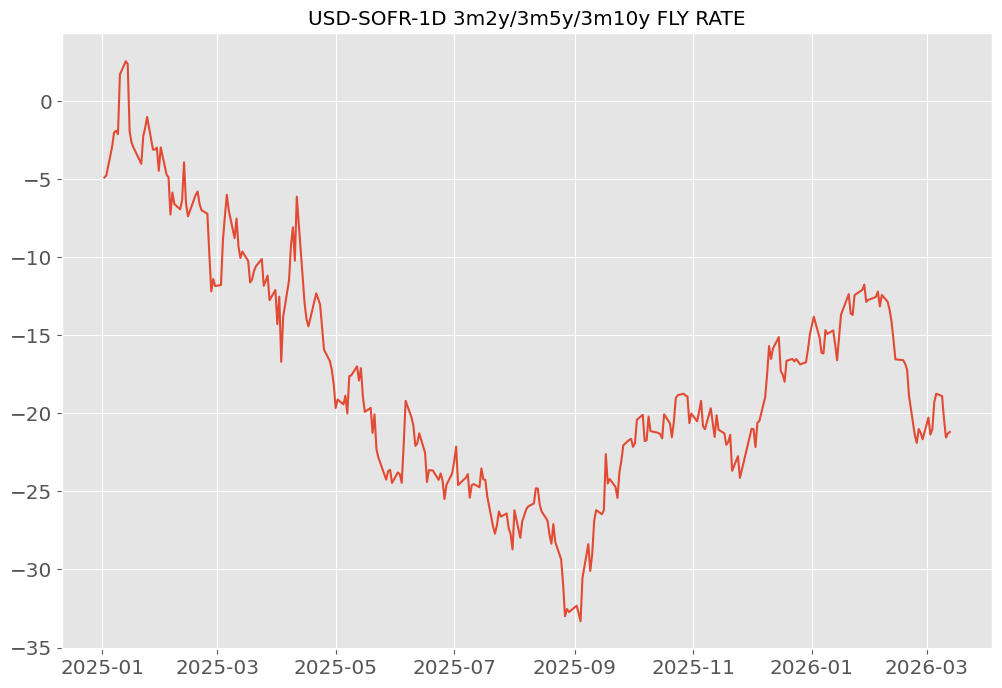

In [12]:
query = IRSwapQuery(
    structure=IRSwapStructure.OUTRIGHT,
    curve="USD-SOFR-1D",
    tenor="3m2y/3m5y/3m10y",
)
df = tb.get_timeseries(start=datetime.date(2025, 1, 2), end=datetime.date(2026, 3, 13), queries=[query], n_jobs=1)
display(df)

plt.figure()
plt.plot(df.index, df[query.col_name()])
plt.title(query.col_name())
plt.show()